# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
| Benedictus Ryu Gunawan | 5054251001|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [3]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll) 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.

data = pd.read_csv('../data/WineQT.csv')
data.index = data['Id']
data.drop('Id', axis=1, inplace=True)
experiment_dataset = [data]
data.head()
data.info()
data.describe()


<class 'pandas.core.frame.DataFrame'>
Index: 1143 entries, 0 to 1597
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 116.1 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


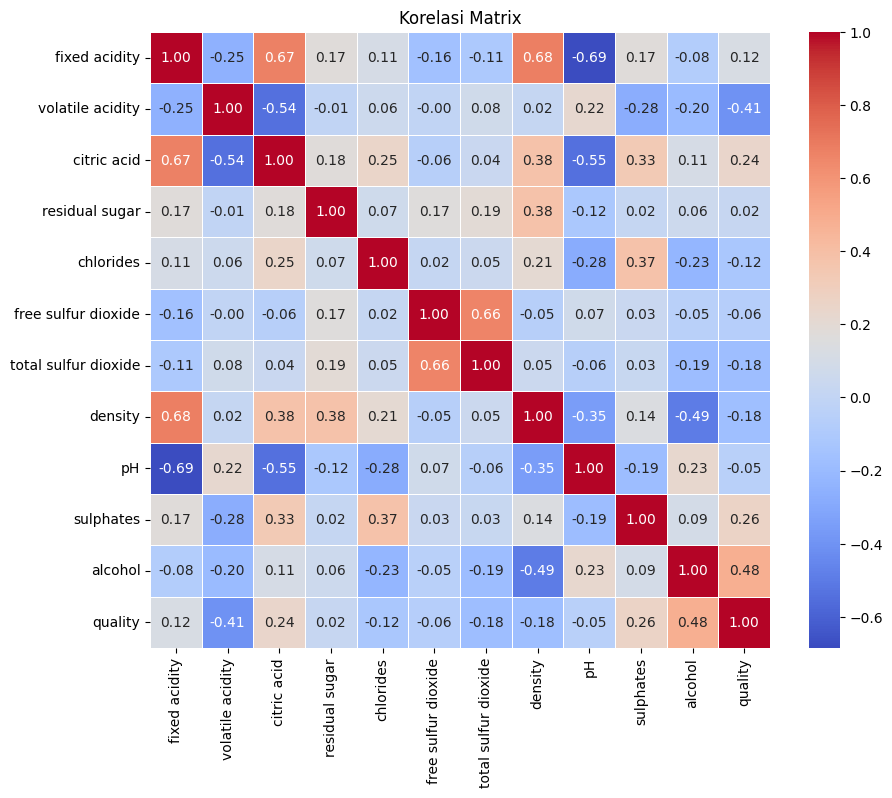

'                      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide   density        pH  sulphates   alcohol   quality\nfixed acidity              1.000000         -0.250728     0.673157        0.171831   0.107889            -0.164831             -0.110628  0.681501 -0.685163   0.174592 -0.075055  0.121970\nvolatile acidity          -0.250728          1.000000    -0.544187       -0.005751   0.056336            -0.001962              0.077748  0.016512  0.221492  -0.276079 -0.203909 -0.407394\ncitric acid                0.673157         -0.544187     1.000000        0.175815   0.245312            -0.057589              0.036871  0.375243 -0.546339   0.331232  0.106250  0.240821\nresidual sugar             0.171831         -0.005751     0.175815        1.000000   0.070863             0.165339              0.190790  0.380147 -0.116959   0.017475  0.058421  0.022002\nchlorides                  0.107889          0.056336 

In [5]:
import seaborn as sns

# Tampilkan Korelasi Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Korelasi Matrix')
plt.show()

display(pd.DataFrame(data.corr()).to_string())

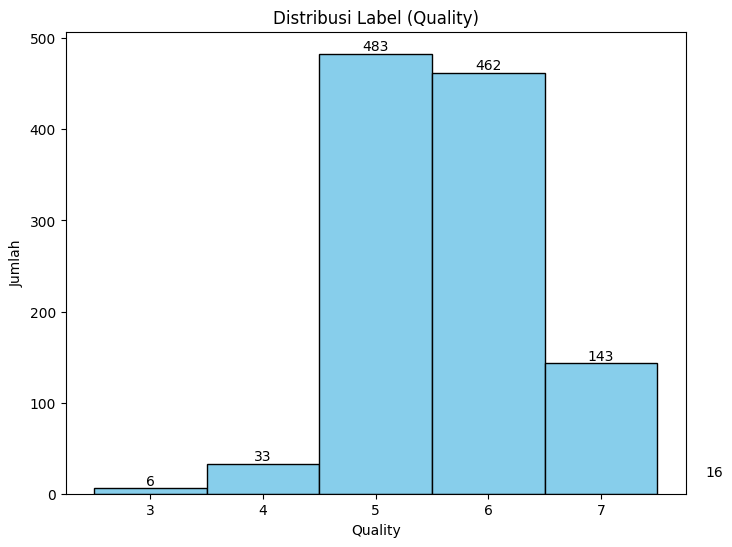

In [6]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.
import seaborn as sns

frequency = data['quality'].value_counts().sort_index()

plt.figure(figsize=(8, 6))
plt.hist(data['quality'], bins=np.arange(data['quality'].min(), data['quality'].max() + 1) - 0.5, edgecolor='black',color='skyblue')
plt.title('Distribusi Label (Quality)')

for i in range(len(frequency)):
    plt.text(frequency.index[i], frequency.values[i], str(frequency.values[i]), ha='center', va='bottom')

plt.xlabel('Quality')
plt.ylabel('Jumlah')
plt.show()

/home/ryz/miniforge3/envs/dsml/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


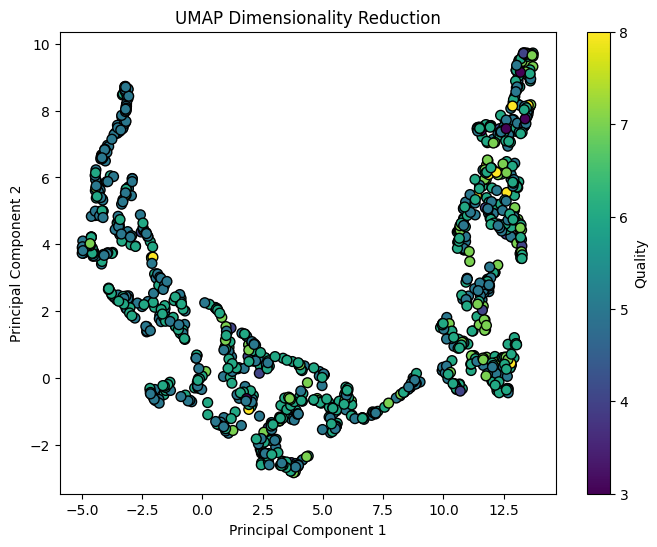

In [7]:
from umap import UMAP

dimensionality_reduction = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
data_reduced = dimensionality_reduction.fit_transform(data.drop('quality', axis=1))
plt.figure(figsize=(8, 6))
plt.scatter(data_reduced[:, 0], data_reduced[:, 1], c=data['quality'], cmap='viridis', edgecolor='k', s=50)
plt.colorbar(label='Quality')
plt.title('UMAP Dimensionality Reduction')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

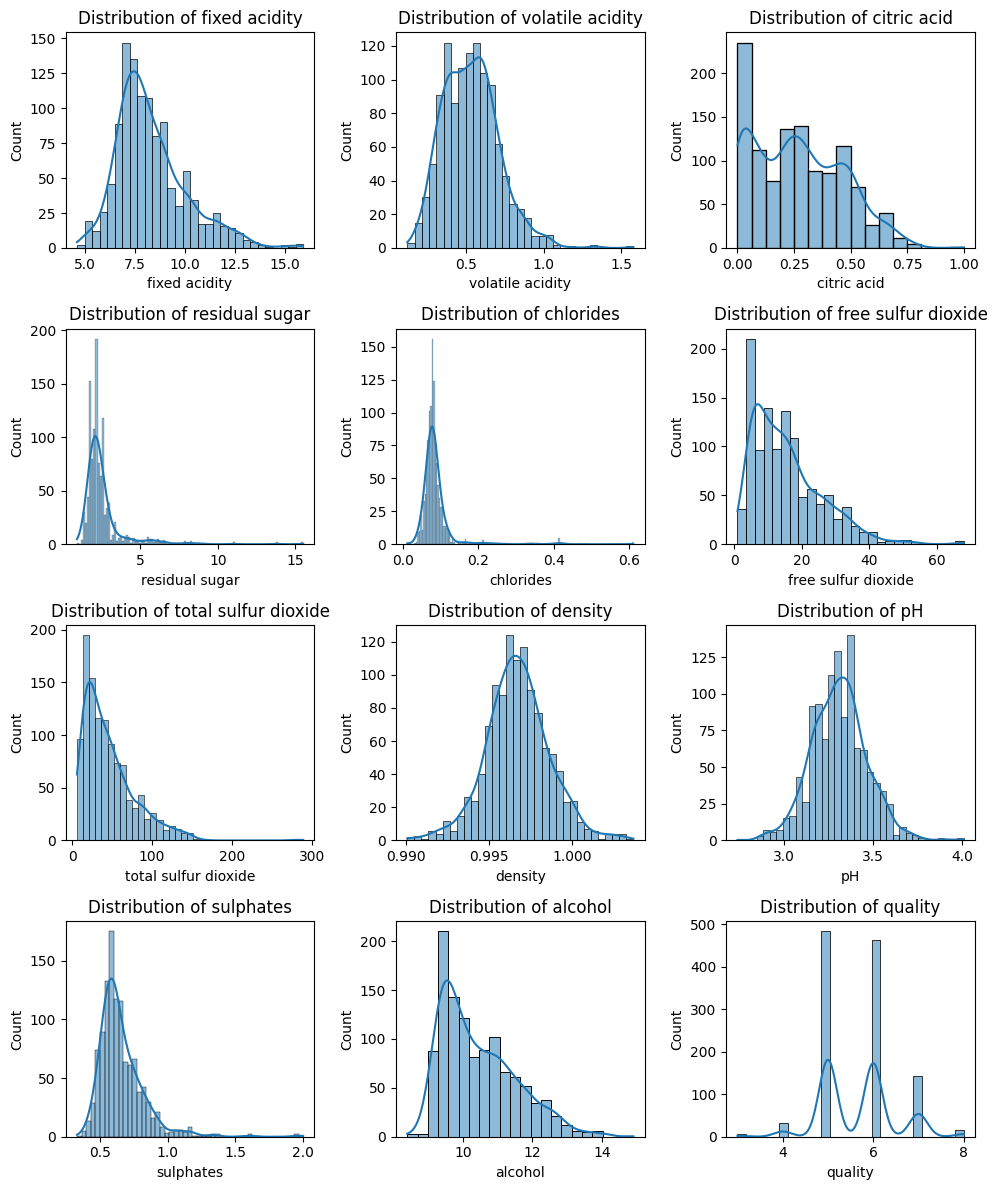

In [8]:
def plot_feature_distribution(data, feature):
    n = len(feature)
    fig,ax = plt.subplots(n//3 + (1 if n % 3 else 0), 3, figsize=(10, 12))
    for i, col in enumerate(feature):
        sns.histplot(data[col], kde=True, ax=ax[i//3, i%3])
        ax[i//3, i%3].set_title(f'Distribution of {col}')
    plt.tight_layout()

plot_feature_distribution(data, data.columns)

In [9]:
# Skewness dan Kurtosis
skewness = data.drop('quality', axis=1).skew().sort_values(ascending=False)
kurtosis = data.drop('quality', axis=1).kurtosis().sort_values(ascending=False)
print("Skewness:\n", skewness)
print("\nKurtosis:\n", kurtosis)

Skewness:
 chlorides               6.026360
residual sugar          4.361096
sulphates               2.497266
total sulfur dioxide    1.665766
free sulfur dioxide     1.231261
fixed acidity           1.044930
alcohol                 0.863313
volatile acidity        0.681547
citric acid             0.371561
pH                      0.221138
density                 0.102395
dtype: float64

Kurtosis:
 chlorides               47.078324
residual sugar          27.675366
sulphates               12.017377
total sulfur dioxide     5.098748
free sulfur dioxide      1.932170
fixed acidity            1.384614
volatile acidity         1.375531
pH                       0.925791
density                  0.888123
alcohol                  0.221179
citric acid             -0.714686
dtype: float64


Banyak dari feature mengalami right-skewed (Artinya secara logis, features scaling dan juga transformasi logaritmik akan berperan penting dalam perhitungan)

# 2. Preprocessing




## 2.1 Missing & Duplicate Checking

Number of Duplicated Rows: 125


/home/ryz/miniforge3/envs/dsml/lib/python3.10/site-packages/missingno/missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(
/home/ryz/miniforge3/envs/dsml/lib/python3.10/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/home/ryz/miniforge3/envs/dsml/lib/python3.10/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


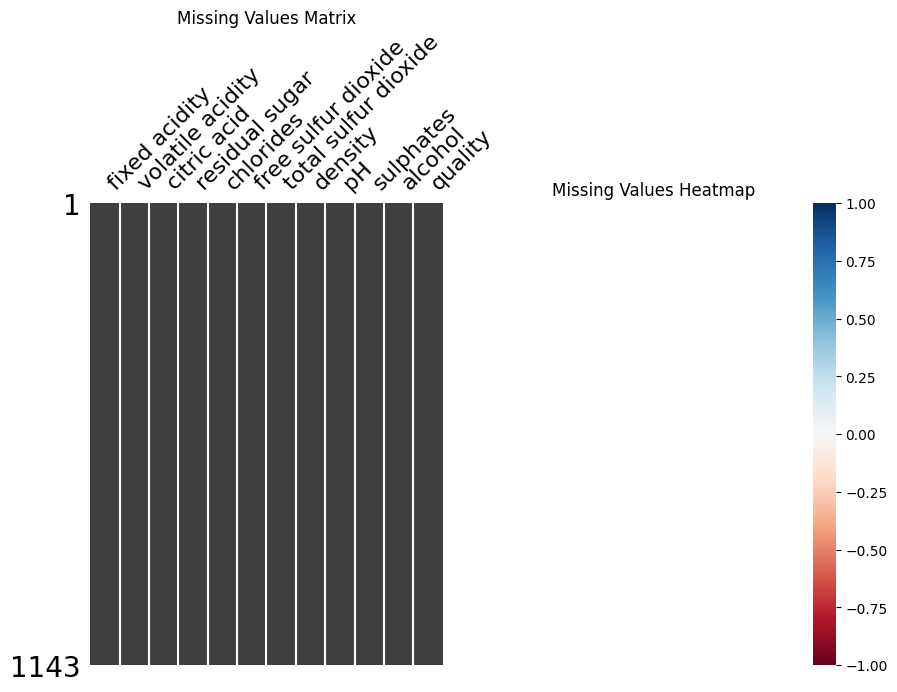

In [10]:
# NaN handling (drop, impute, etc.), duplicate handling, dan lain-lain.

import missingno as msno

fig,ax = plt.subplots(1,2,figsize=(10,6))
ax[0].set_title('Missing Values Matrix')
msno.matrix(data, ax=ax[0])
ax[1].set_title('Missing Values Heatmap')
msno.heatmap(data, ax=ax[1])

print(f"Number of Duplicated Rows: {data.duplicated().sum()}")


Tidak ada duplicate dalam dataset ini sehingga, tidak perlu adanya penanganan pada missing dan duplicate values

## 2.2 See the outlier

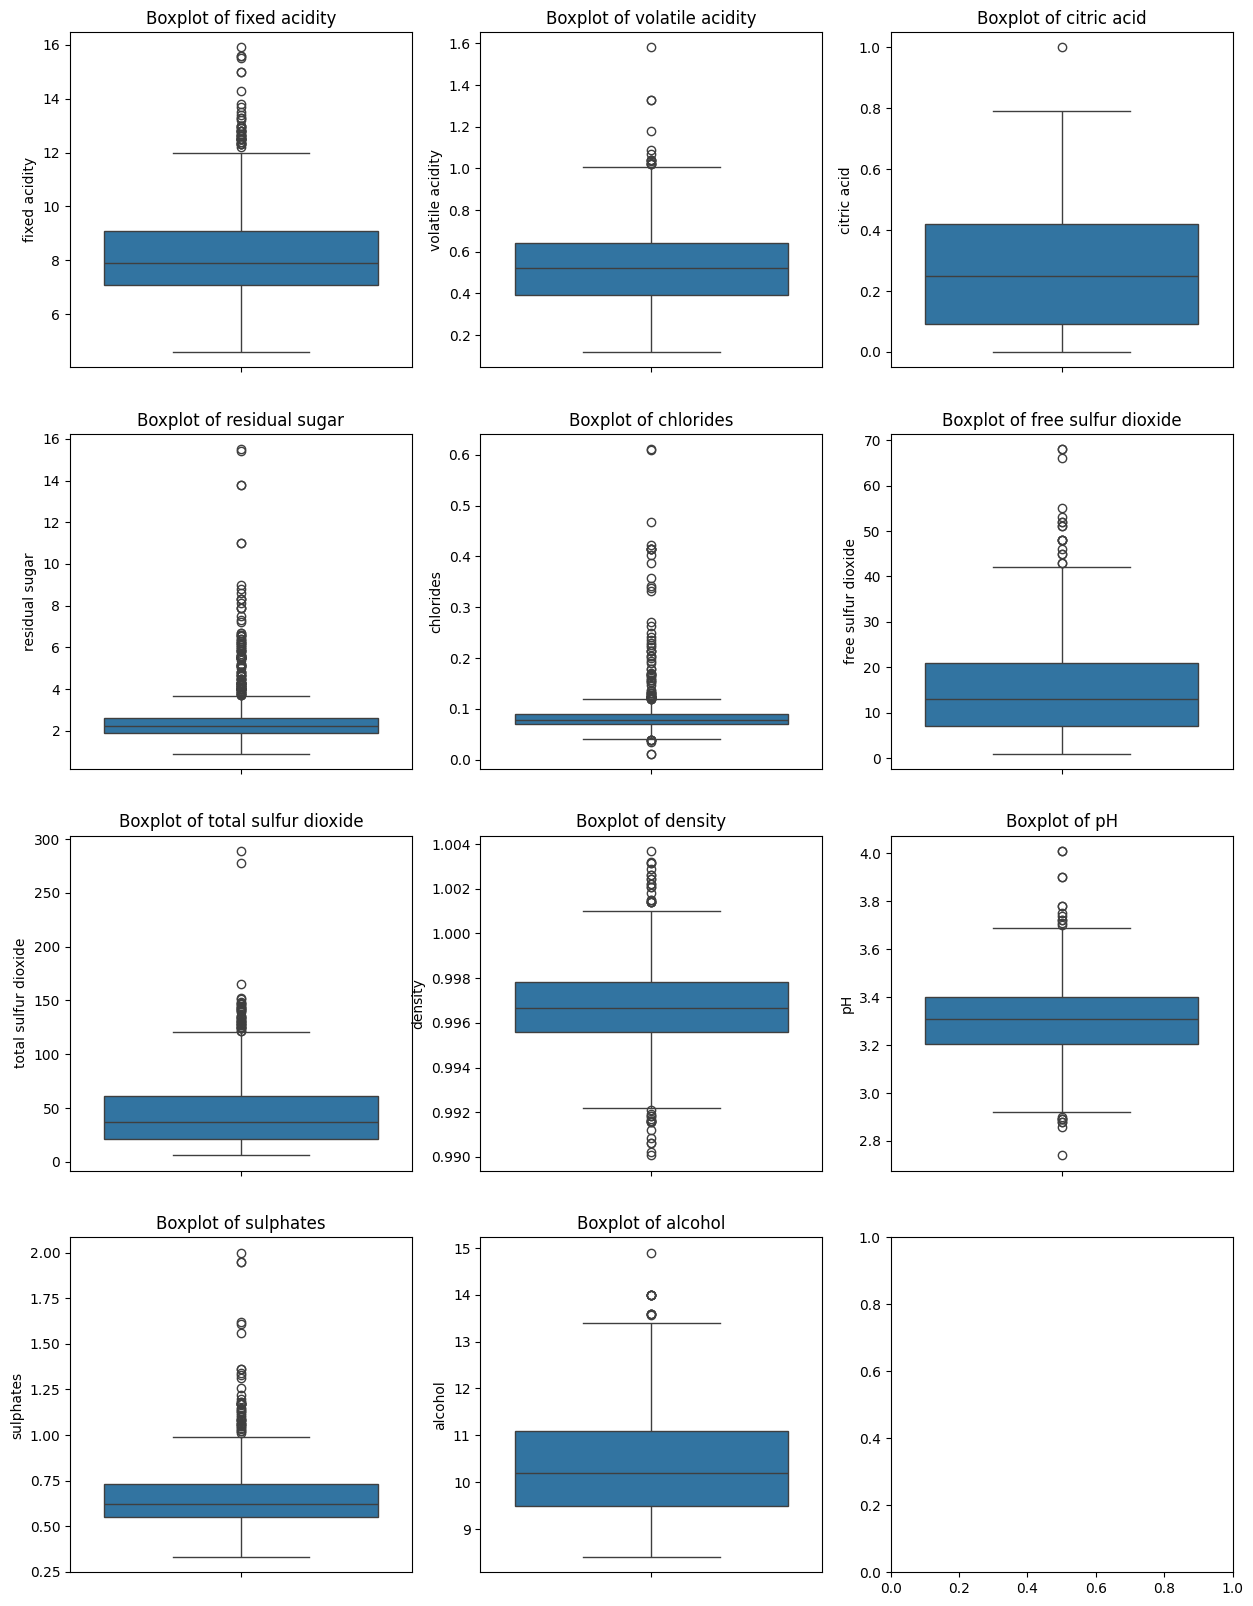

In [11]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)
def plot_boxplots(data):
    fig,ax = plt.subplots(4,3,figsize=(15,20))
    for i, column in enumerate(data.columns[:-1]):
        sns.boxplot(data[column], ax=ax[i//3, i%3])
        ax[i//3, i%3].set_title(f'Boxplot of {column}')

plot_boxplots(data)

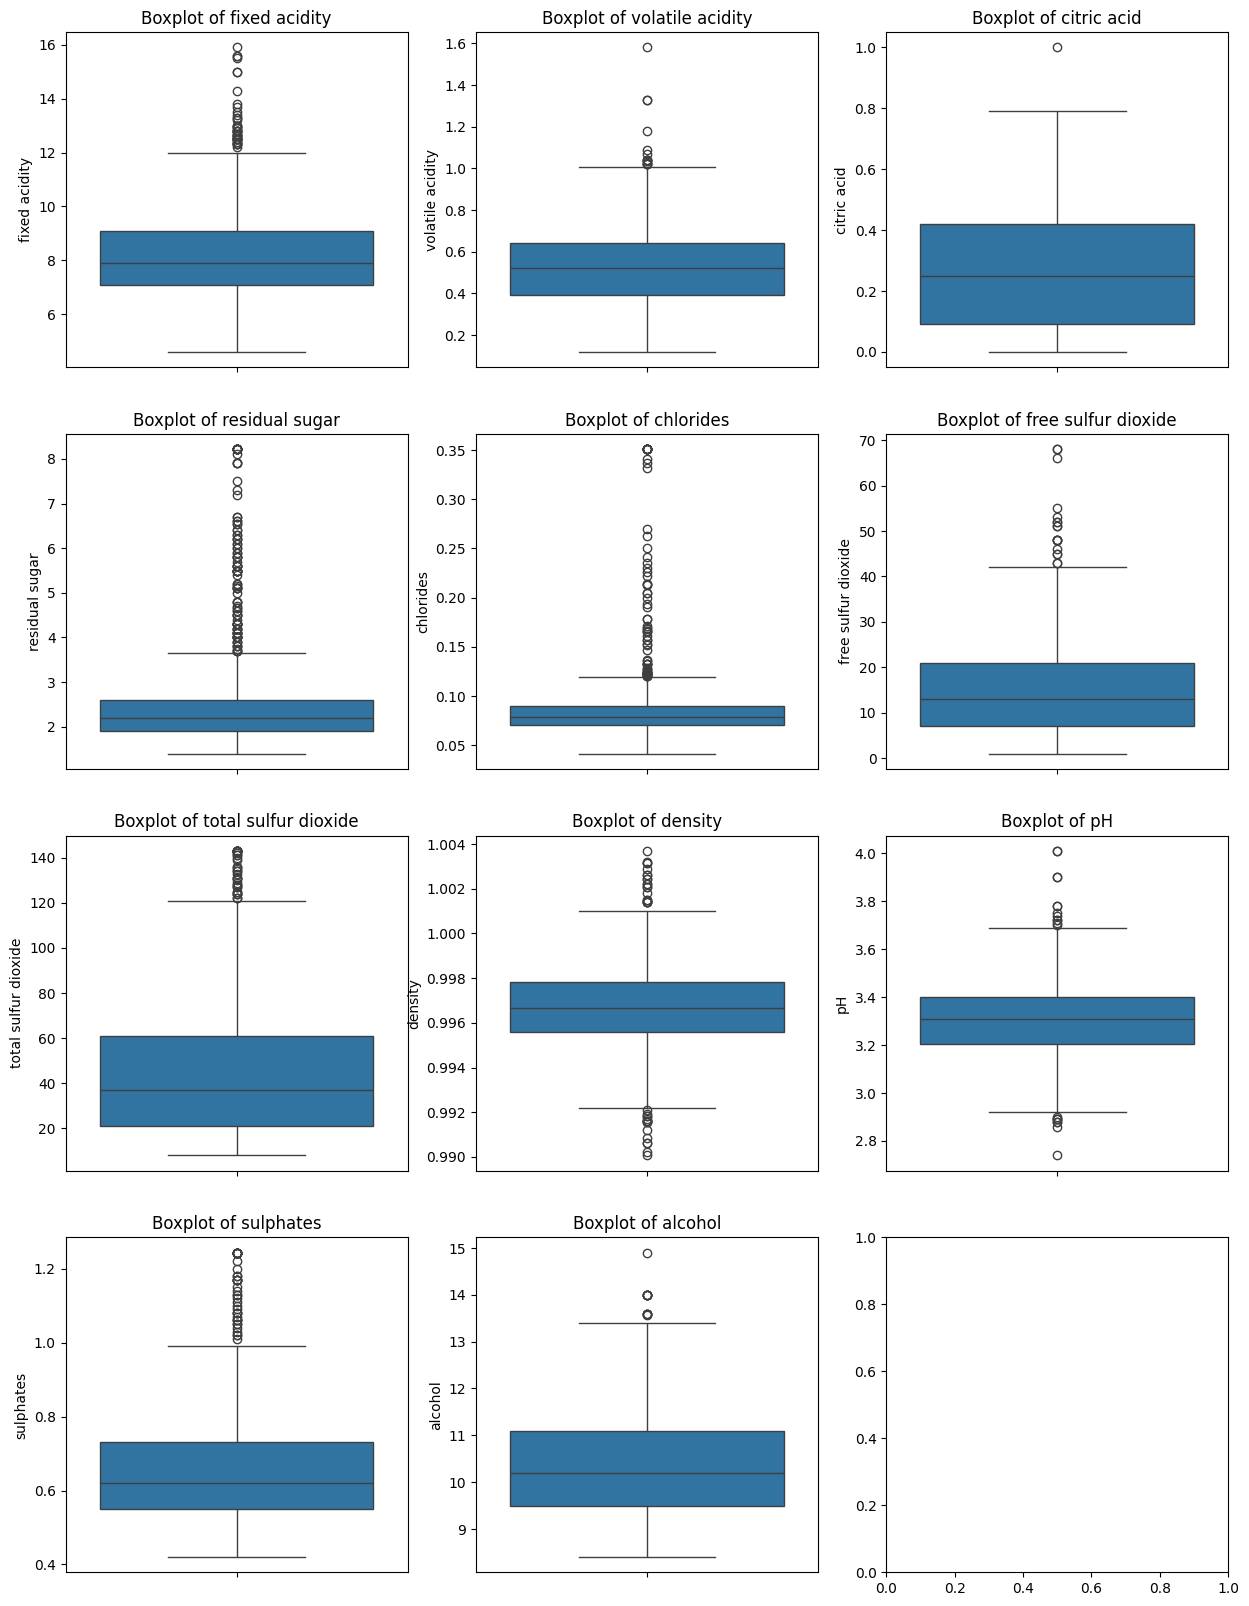

In [12]:
# Clip Outlier Handling

outlier_features = [
    "chlorides",
    "residual sugar",
    "sulphates",
    "total sulfur dioxide"
]

df_clip = data.copy()

for col in outlier_features:
    lower = df_clip[col].quantile(0.01)
    upper = df_clip[col].quantile(0.99)

    df_clip[col] = df_clip[col].clip(lower, upper)

experiment_dataset.append(df_clip)
plot_boxplots(df_clip)

## 2.3 Feature Engineering

In [13]:
def feature_engineering(data):
    data['total_acidity'] = data['fixed acidity'] + data['volatile acidity']
    data['density_alcohol_ratio'] = data['density'] / data['alcohol']
    eps = 1e-6

    data["total_acidity"] = (
        data["fixed acidity"]
        + data["volatile acidity"]
        + data["citric acid"]
    )

    data["volatile_fixed_ratio"] = (
        data["volatile acidity"] / (data["fixed acidity"] + eps)
    )

    data["free_total_sulfur_ratio"] = (
        data["free sulfur dioxide"]
        / (data["total sulfur dioxide"] + eps)
    )

    data["bound_sulfur_dioxide"] = (
        data["total sulfur dioxide"]
        - data["free sulfur dioxide"]
    )

    data["alcohol_density_ratio"] = (
        data["alcohol"] / (data["density"] + eps)
    )

    data["sugar_alcohol_ratio"] = (
        data["residual sugar"] / (data["alcohol"] + eps)
    )

    data["sulphates_chlorides_ratio"] = (
        data["sulphates"] / (data["chlorides"] + eps)
    )

    data["acid_pH_interaction"] = (
        data["fixed acidity"] * data["pH"]
    )

    engineered_features = [
        "total_acidity",
        "volatile_fixed_ratio",
        "free_total_sulfur_ratio",
        "bound_sulfur_dioxide",
        "alcohol_density_ratio",
        "sugar_alcohol_ratio",
        "sulphates_chlorides_ratio",
        "acid_pH_interaction"
    ]

    data[[f"log_{col}" for col in engineered_features]] = (
        data[engineered_features]
        .clip(lower=0)
        .apply(np.log1p)
        .set_axis(
            [f"log_{col}" for col in engineered_features],
            axis=1
        )
    )
        
    return data

df_fe = feature_engineering(df_clip.copy())
experiment_dataset.append(df_fe)

## 2.4 Feature Scaling

In [14]:
from sklearn.preprocessing import StandardScaler

df_scaled = df_fe.copy()
target = df_scaled['quality']
df_scaled.drop('quality', axis=1, inplace=True)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_scaled)
df_scaled = pd.DataFrame(scaled_features, columns=df_scaled.columns)
df_scaled['quality'] = target.values

experiment_dataset.append(df_scaled)
df_scaled

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,...,acid_pH_interaction,log_total_acidity,log_volatile_fixed_ratio,log_free_total_sulfur_ratio,log_bound_sulfur_dioxide,log_alcohol_density_ratio,log_sugar_alcohol_ratio,log_sulphates_chlorides_ratio,log_acid_pH_interaction,quality
0,-0.521580,0.939332,-1.365027,-0.522118,-0.254591,-0.450467,-0.371147,0.555854,1.270695,-0.620749,...,-0.278779,-0.518642,0.961405,-0.327824,0.057825,-0.996741,-0.351468,-0.218238,-0.216357,5
1,-0.292593,1.941813,-1.365027,0.082312,0.304171,0.915920,0.682977,0.036165,-0.708928,0.165648,...,-0.487126,-0.162138,1.587285,0.006665,0.811360,-0.578901,0.280070,-0.396860,-0.450955,5
2,-0.292593,1.273492,-1.161568,-0.176730,0.151782,-0.060071,0.267716,0.140103,-0.325775,-0.030951,...,-0.390966,-0.210021,1.059658,-0.647636,0.717908,-0.580870,-0.021896,-0.343307,-0.341561,5
3,1.653789,-1.399789,1.483400,-0.522118,-0.279989,0.135127,0.459375,0.659792,-0.964363,-0.489683,...,1.656336,1.557041,-1.528341,-0.608196,0.841067,-0.590704,-0.436378,-0.073582,1.617221,6
4,-0.521580,0.939332,-1.365027,-0.522118,-0.254591,-0.450467,-0.371147,0.555854,1.270695,-0.620749,...,-0.278779,-0.518642,0.961405,-0.327824,0.057825,-0.996741,-0.351468,-0.218238,-0.216357,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,-1.151292,-0.118842,-0.703785,-0.176730,-0.254591,1.306316,-0.179488,-0.514707,0.695966,0.624379,...,-1.188600,-1.305424,0.486071,2.080573,-0.837853,0.570757,-0.280256,0.667681,-1.314242,6
1139,-0.865059,0.493785,-0.958109,-0.522118,-0.457777,1.208717,-0.243374,-0.114545,0.695966,1.083111,...,-0.837247,-0.912193,0.842866,2.142768,-0.950288,-0.880633,-0.373310,1.289938,-0.866638,6
1140,-1.208538,0.382399,-0.958109,-0.435771,0.100985,1.599113,-0.051715,-0.951246,0.887542,-0.489683,...,-1.220653,-1.349190,1.036799,2.092543,-0.734422,0.118915,-0.471555,-0.614756,-1.356752,5
1141,-1.380278,0.103932,-0.856379,-0.263077,-0.610166,2.282306,0.171887,-0.836914,1.334554,0.689912,...,-1.348456,-1.596026,0.913791,2.287454,-0.734422,0.755660,-0.410060,1.341252,-1.529248,6


In [15]:
from sklearn.preprocessing import MinMaxScaler

df_minmax = df_fe.copy()
target = df_minmax['quality']
df_minmax.drop('quality', axis=1, inplace=True)
minmax_scaler = MinMaxScaler()
minmax_scaled_features = minmax_scaler.fit_transform(df_minmax)
df_minmax = pd.DataFrame(minmax_scaled_features, columns=df_minmax.columns)
df_minmax['quality'] = target.values

experiment_dataset.append(df_minmax)
df_minmax

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,...,acid_pH_interaction,log_total_acidity,log_volatile_fixed_ratio,log_free_total_sulfur_ratio,log_bound_sulfur_dioxide,log_alcohol_density_ratio,log_sugar_alcohol_ratio,log_sulphates_chlorides_ratio,log_acid_pH_interaction,quality
0,0.247788,0.397260,0.00,0.073357,0.111750,0.149254,0.192593,0.567548,0.606299,0.170068,...,0.284779,0.352380,0.438513,0.432188,0.515834,0.196380,0.145696,0.496245,0.393967,5
1,0.283186,0.520548,0.00,0.176056,0.182846,0.358209,0.437037,0.494126,0.362205,0.315841,...,0.250902,0.410830,0.532569,0.493865,0.683718,0.269516,0.237759,0.471489,0.354222,5
2,0.283186,0.438356,0.04,0.132042,0.163457,0.208955,0.340741,0.508811,0.409449,0.279397,...,0.266537,0.402980,0.453278,0.373219,0.662897,0.269172,0.193739,0.478911,0.372755,5
3,0.584071,0.109589,0.56,0.073357,0.108519,0.238806,0.385185,0.582232,0.330709,0.194363,...,0.599425,0.692698,0.064358,0.380491,0.690336,0.267450,0.133318,0.516294,0.704606,6
4,0.247788,0.397260,0.00,0.073357,0.111750,0.149254,0.192593,0.567548,0.606299,0.170068,...,0.284779,0.352380,0.438513,0.432188,0.515834,0.196380,0.145696,0.496245,0.393967,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,0.150442,0.267123,0.13,0.132042,0.111750,0.417910,0.237037,0.416300,0.535433,0.400875,...,0.136844,0.223383,0.367080,0.876272,0.316282,0.470747,0.156077,0.619031,0.207967,6
1139,0.194690,0.342466,0.08,0.073357,0.085897,0.402985,0.222222,0.472834,0.535433,0.485909,...,0.193973,0.287855,0.420699,0.887740,0.291232,0.216703,0.142512,0.705275,0.283798,6
1140,0.141593,0.328767,0.08,0.088028,0.156993,0.462687,0.266667,0.354626,0.559055,0.194363,...,0.131632,0.216208,0.449843,0.878479,0.339326,0.391659,0.128190,0.441289,0.200765,5
1141,0.115044,0.294521,0.10,0.117371,0.066507,0.567164,0.318519,0.370778,0.614173,0.413022,...,0.110851,0.175738,0.431357,0.914418,0.339326,0.503112,0.137155,0.712387,0.171541,6


In [16]:
from sklearn.preprocessing import RobustScaler

df_robust = df_fe.copy()
target = df_robust['quality']
df_robust.drop('quality', axis=1, inplace=True)
robust_scaler = RobustScaler()
robust_scaled_features = robust_scaler.fit_transform(df_robust)
df_robust = pd.DataFrame(robust_scaled_features, columns=df_robust.columns)
df_robust['quality'] = target.values

experiment_dataset.append(df_robust)
df_robust

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,...,acid_pH_interaction,log_total_acidity,log_volatile_fixed_ratio,log_free_total_sulfur_ratio,log_bound_sulfur_dioxide,log_alcohol_density_ratio,log_sugar_alcohol_ratio,log_sulphates_chlorides_ratio,log_acid_pH_interaction,quality
0,-0.25,0.727273,-0.757576,-0.428571,-0.15,-0.142857,-0.075,0.492308,1.025641,-0.333333,...,-0.041586,-0.316148,0.687034,-0.238983,0.077417,-0.508737,-0.125551,-0.142785,-0.042855,5
1,-0.05,1.454545,-0.757576,0.571429,0.95,0.857143,0.750,0.052747,-0.564103,0.333333,...,-0.213000,-0.028743,1.118949,-0.008505,0.596263,-0.238961,0.738210,-0.295115,-0.223727,5
2,-0.05,0.969697,-0.636364,0.142857,0.65,0.142857,0.425,0.140659,-0.256410,0.166667,...,-0.133886,-0.067345,0.754838,-0.459348,0.531917,-0.240232,0.325208,-0.249445,-0.139386,5
3,1.65,-0.969697,0.939394,-0.428571,-0.20,0.285714,0.575,0.580220,-0.769231,-0.222222,...,1.550503,1.357220,-1.031117,-0.432173,0.616717,-0.246581,-0.241682,-0.019420,1.370808,6
4,-0.25,0.727273,-0.757576,-0.428571,-0.15,-0.142857,-0.075,0.492308,1.025641,-0.333333,...,-0.041586,-0.316148,0.687034,-0.238983,0.077417,-0.508737,-0.125551,-0.142785,-0.042855,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,-0.80,-0.040404,-0.363636,0.142857,-0.15,1.142857,0.075,-0.413187,0.564103,0.722222,...,-0.790128,-0.950434,0.359011,1.420513,-0.539300,0.503313,-0.028153,0.612737,-0.889308,6
1139,-0.55,0.404040,-0.515152,-0.428571,-0.55,1.071429,0.025,-0.074725,0.564103,1.111111,...,-0.501057,-0.633419,0.605232,1.463368,-0.616717,-0.433773,-0.155424,1.143405,-0.544213,6
1140,-0.85,0.323232,-0.515152,-0.285714,0.55,1.357143,0.175,-0.782418,0.717949,-0.222222,...,-0.816499,-0.985717,0.739063,1.428760,-0.468083,0.211582,-0.289795,-0.480940,-0.922084,5
1141,-1.00,0.121212,-0.454545,0.000000,-0.85,1.857143,0.350,-0.685714,1.076923,0.777778,...,-0.921647,-1.184710,0.654176,1.563063,-0.468083,0.622695,-0.205688,1.187167,-1.055075,6


## 2.5 SMOTE

In [17]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

X_smote_base = df_scaled.drop('quality', axis=1)
y_smote_base = df_scaled['quality']
X_train_smote_base, X_test_smote_holdout, y_train_smote_base, y_test_smote_holdout = train_test_split(
    X_smote_base, y_smote_base, test_size=0.2, random_state=42, stratify=y_smote_base
)

smote = SMOTE(random_state=42, k_neighbors=1)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_smote_base, y_train_smote_base)

df_smote_train_resampled = pd.DataFrame(X_train_resampled, columns=X_smote_base.columns)
df_smote_train_resampled['quality'] = y_train_resampled.values
print(f"Train before SMOTE: {y_train_smote_base.value_counts().sort_index().to_dict()}")
print(f"Train after SMOTE: {y_train_resampled.value_counts().sort_index().to_dict()}")
print(f"Holdout (untouched): {y_test_smote_holdout.value_counts().sort_index().to_dict()}")


Train before SMOTE: {3: 5, 4: 26, 5: 386, 6: 370, 7: 114, 8: 13}
Train after SMOTE: {3: 386, 4: 386, 5: 386, 6: 386, 7: 386, 8: 386}
Holdout (untouched): {3: 1, 4: 7, 5: 97, 6: 92, 7: 29, 8: 3}


# 3. Eksperimen Model KNN


In [18]:
# Create KNN From scratch

class KNN:
    def __init__(self, k=3, distances_technique='euclidean', weights='uniform'):
        self.k = k
        self.distances_technique = distances_technique
        self.weights = weights

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return np.array(predictions)

    def _predict(self, x):
        # Hitung jarak antara x dan semua titik data dalam X_train\
        if self.distances_technique == 'euclidean':
            distances = np.linalg.norm(self.X_train - x, axis=1)
        elif self.distances_technique == 'manhattan':
            distances = np.sum(np.abs(self.X_train - x), axis=1)
        elif self.distances_technique == 'minkowski':
            p = 3  # Contoh nilai p untuk Minkowski
            distances = np.sum(np.abs(self.X_train - x) ** p, axis=1) ** (1/p)
        else:
            raise ValueError("Unknown distance technique")
        

        # Urutkan jarak dan ambil indeks dari k tetangga terdekat
        k_indices = np.argsort(distances)[:self.k]

        if self.weights == 'distance':
            # Ambil jarak dari k tetangga terdekat
            k_nearest_distances = distances[k_indices]
            # Hitung bobot sebagai invers dari jarak
            weights = 1 / (k_nearest_distances + 1e-5)  # Tambahkan epsilon untuk menghindari pembagian dengan nol
            # Ambil label dari k tetangga terdekat
            k_nearest_labels = [self.y_train[i] for i in k_indices]
            # Hitung label yang paling umum dengan mempertimbangkan bobot
            label_weights = {}
            for label, weight in zip(k_nearest_labels, weights):
                if label in label_weights:
                    label_weights[label] += weight
                else:
                    label_weights[label] = weight
            most_common = max(label_weights, key=label_weights.get)
        elif self.weights == 'uniform':
            # Ambil label dari k tetangga terdekat
            k_nearest_labels = [self.y_train[i] for i in k_indices]
            # Hitung label yang paling umum
            most_common = max(set(k_nearest_labels), key=k_nearest_labels.count)
        else:
            raise ValueError("Unknown weights technique")


        return most_common

model = KNN(k=3)
model

In [19]:
from dataclasses import dataclass

@dataclass
class ModelEvaluation:
    data_version: str
    model_version: str
    accuracy: float
    precision: float
    recall: float
    f1_score: float

# 4. Evaluasi Model


## 4.1 Evaluasi KNN From Scratch

In [20]:
# Testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_scaled.drop('quality', axis=1), df_scaled['quality'], test_size=0.2, random_state=42, stratify=df_scaled['quality'])

In [21]:
# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_true, y_pred):
    print("Confusion Matrix:")
    display(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"F1 Score: {f1_score(y_true, y_pred, average='weighted'):.4f}")

In [22]:
model.fit(X_train.values, y_train.values)
evaluate_model(y_test.values, model.predict(X_test.values))

Confusion Matrix:


array([[ 0,  0,  1,  0,  0,  0],
       [ 0,  0,  3,  3,  1,  0],
       [ 1,  3, 67, 22,  3,  1],
       [ 0,  2, 23, 55,  7,  5],
       [ 0,  1,  4, 14,  8,  2],
       [ 0,  0,  0,  1,  1,  1]])


Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.68      0.69      0.69        97
           6       0.58      0.60      0.59        92
           7       0.40      0.28      0.33        29
           8       0.11      0.33      0.17         3

    accuracy                           0.57       229
   macro avg       0.30      0.32      0.29       229
weighted avg       0.57      0.57      0.57       229

Accuracy: 0.5721
Precision: 0.5743
Recall: 0.5721
F1 Score: 0.5709


In [23]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train.values, y_train.values)
model.predict(X_test.values)
evaluate_model(y_test.values, model.predict(X_test.values))

Confusion Matrix:


array([[ 0,  0,  1,  0,  0,  0],
       [ 0,  0,  3,  3,  1,  0],
       [ 1,  3, 68, 22,  3,  0],
       [ 0,  2, 23, 59,  7,  1],
       [ 0,  1,  4, 15,  8,  1],
       [ 0,  0,  0,  2,  1,  0]])


Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.69      0.70      0.69        97
           6       0.58      0.64      0.61        92
           7       0.40      0.28      0.33        29
           8       0.00      0.00      0.00         3

    accuracy                           0.59       229
   macro avg       0.28      0.27      0.27       229
weighted avg       0.58      0.59      0.58       229

Accuracy: 0.5895
Precision: 0.5763
Recall: 0.5895
F1 Score: 0.5809


Hasil from scratch sama hasil dari model bawaan sudah sama, karena kedua model tersebut sebenarnya adalah lazy learners

## 4.2 Evaluasi Dataset

In [24]:
def evaluate_dataset(X_train, X_test, y_train, y_test, model, data_version, model_version):
    model.fit(X_train.values, y_train.values)
    y_pred = model.predict(X_test.values)
    
    accuracy = accuracy_score(y_test.values, y_pred)
    precision = precision_score(y_test.values, y_pred, average='weighted')
    recall = recall_score(y_test.values, y_pred, average='weighted')
    f1 = f1_score(y_test.values, y_pred, average='weighted')
    
    
    return accuracy, precision, recall, f1

In [25]:
from sklearn.model_selection import KFold, cross_val_score
from imblearn.over_sampling import SMOTE

def evaluate_all_datasets(model):
    evaluations = []
    for dataset in experiment_dataset:
        X_train, X_test, y_train, y_test = train_test_split(dataset.drop('quality', axis=1), dataset['quality'], test_size=0.2, random_state=42, stratify=dataset['quality'])
        KF = KFold(n_splits=5, shuffle=True, random_state=42)
        eval = ModelEvaluation(data_version="baseline" if dataset.equals(data) else  "clip" if dataset.equals(df_clip) else "fe" if dataset.equals(df_fe) else "standard" if dataset.equals(df_scaled) else "minmax" if dataset.equals(df_minmax) else "robust", model_version="KNN", accuracy=0, precision=0, recall=0, f1_score=0)
        for train_index, test_index in KF.split(X_train):
            X_train_fold, X_test_fold = X_train.iloc[train_index], X_train.iloc[test_index]
            y_train_fold, y_test_fold = y_train.iloc[train_index], y_train.iloc[test_index]
            model.fit(X_train_fold.values, y_train_fold.values)
            y_pred_fold = model.predict(X_test_fold.values)

            accuracy, precision, recall, f1 = evaluate_dataset(X_train_fold, X_test_fold, y_train_fold, y_test_fold, model, eval.data_version, eval.model_version)
            eval.accuracy += accuracy
            eval.precision += precision
            eval.recall += recall
            eval.f1_score += f1
        eval.accuracy /= KF.get_n_splits()
        eval.precision /= KF.get_n_splits()
        eval.recall /= KF.get_n_splits()
        eval.f1_score /= KF.get_n_splits()
        evaluations.append(eval)

    return evaluations

def evaluate_with_train_only_smote(model, dataset, label):
    # CORRECT SMOTE: split first, then SMOTE each train fold only. Test fold stays untouched.
    # k_neighbors=1 because quality=3/8 have <6 samples per fold (default k=5 would crash).
    X_train, X_test, y_train, y_test = train_test_split(dataset.drop('quality', axis=1), dataset['quality'], test_size=0.2, random_state=42, stratify=dataset['quality'])
    KF = KFold(n_splits=5, shuffle=True, random_state=42)
    smote = SMOTE(random_state=42, k_neighbors=1)
    eval = ModelEvaluation(data_version=label, model_version="KNN", accuracy=0, precision=0, recall=0, f1_score=0)
    for train_index, test_index in KF.split(X_train):
        X_tr, X_te = X_train.iloc[train_index], X_train.iloc[test_index]
        y_tr, y_te = y_train.iloc[train_index], y_train.iloc[test_index]
        X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)
        model.fit(np.asarray(X_tr_res), np.asarray(y_tr_res))
        y_pred = model.predict(np.asarray(X_te))
        eval.accuracy += accuracy_score(np.asarray(y_te), y_pred)
        eval.precision += precision_score(np.asarray(y_te), y_pred, average='weighted', zero_division=0)
        eval.recall += recall_score(np.asarray(y_te), y_pred, average='weighted', zero_division=0)
        eval.f1_score += f1_score(np.asarray(y_te), y_pred, average='weighted', zero_division=0)
    eval.accuracy /= KF.get_n_splits()
    eval.precision /= KF.get_n_splits()
    eval.recall /= KF.get_n_splits()
    eval.f1_score /= KF.get_n_splits()
    return eval

evaluations = evaluate_all_datasets(model)
evaluations.append(evaluate_with_train_only_smote(model, df_scaled, "smote"))

/home/ryz/miniforge3/envs/dsml/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ryz/miniforge3/envs/dsml/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ryz/miniforge3/envs/dsml/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", re

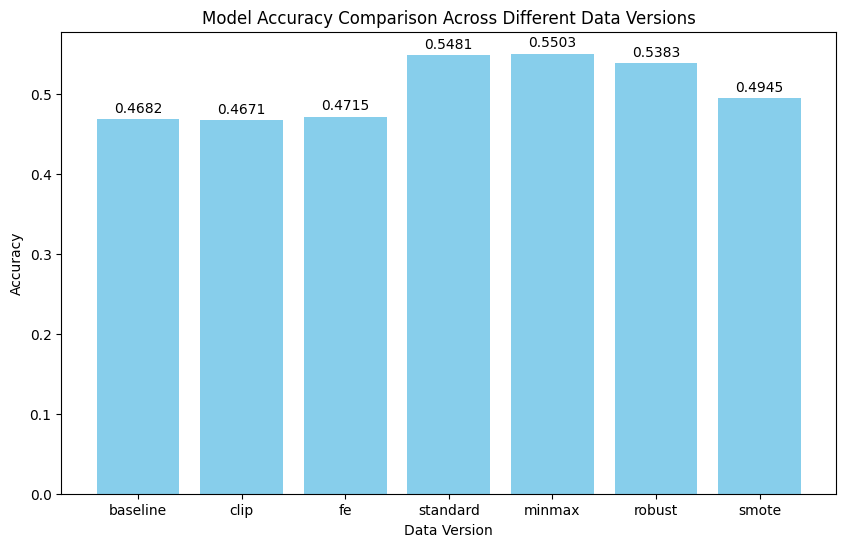

In [26]:
plt.figure(figsize=(10, 6))
data_versions = [e.data_version for e in evaluations]
accuracies = [e.accuracy for e in evaluations]
plt.bar(data_versions, accuracies, color='skyblue')
plt.title('Model Accuracy Comparison Across Different Data Versions')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center', va='bottom')
plt.xlabel('Data Version')
plt.ylabel('Accuracy')
plt.show()

## 4.3 Evaluasi Hyperparameter Model

In [27]:
X_train, X_test, y_train, y_test = train_test_split(df_minmax.drop('quality', axis=1), df_minmax['quality'], test_size=0.2, random_state=42, stratify=df_minmax['quality'])

In [28]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_neighbors': [i for i in range(1, 20,2)],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(model, params, cv=5, scoring='accuracy')
grid_search.fit(X_train.values, y_train.values)

print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy found: ", grid_search.best_score_)


Best parameters found:  {'metric': 'euclidean', 'n_neighbors': 17, 'weights': 'distance'}
Best accuracy found:  0.6433255269320843


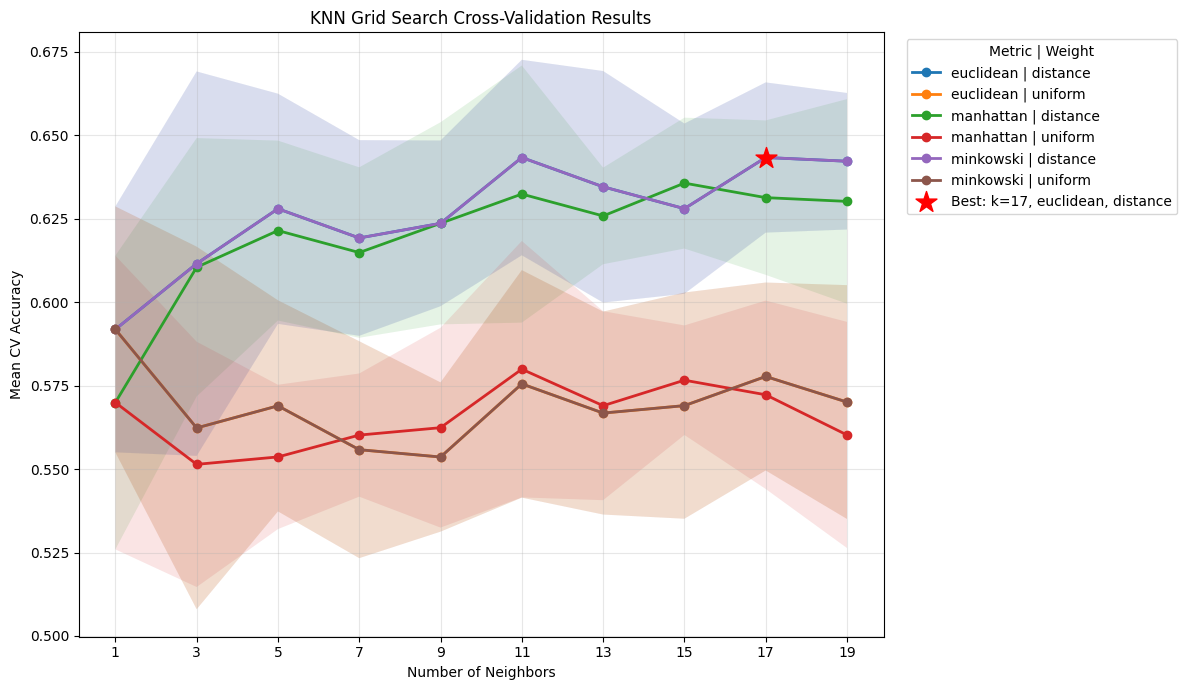

In [29]:
# Convert all GridSearchCV results to DataFrame
results = pd.DataFrame(grid_search.cv_results_)

# Convert parameter columns to convenient types
results["param_n_neighbors"] = results["param_n_neighbors"].astype(int)

# Sort for consistent plotting
results = results.sort_values(
    by=["param_metric", "param_weights", "param_n_neighbors"]
)

# Plot all parameter combinations
fig, ax = plt.subplots(figsize=(12, 7))

for (metric, weight), group in results.groupby(
    ["param_metric", "param_weights"]
):
    group = group.sort_values("param_n_neighbors")

    ax.plot(
        group["param_n_neighbors"],
        group["mean_test_score"],
        marker="o",
        linewidth=2,
        label=f"{metric} | {weight}"
    )

    # CV standard deviation band
    ax.fill_between(
        group["param_n_neighbors"],
        group["mean_test_score"] - group["std_test_score"],
        group["mean_test_score"] + group["std_test_score"],
        alpha=0.12
    )

# Mark the best result
best_index = results["mean_test_score"].idxmax()
best_result = results.loc[best_index]

ax.scatter(
    best_result["param_n_neighbors"],
    best_result["mean_test_score"],
    color="red",
    marker="*",
    s=250,
    zorder=5,
    label=(
        f"Best: k={best_result['param_n_neighbors']}, "
        f"{best_result['param_metric']}, "
        f"{best_result['param_weights']}"
    )
)

ax.set_title("KNN Grid Search Cross-Validation Results")
ax.set_xlabel("Number of Neighbors")
ax.set_ylabel("Mean CV Accuracy")
ax.set_xticks(sorted(results["param_n_neighbors"].unique()))
ax.grid(alpha=0.3)
ax.legend(title="Metric | Weight", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

# 5. Analisis

Berdasakan hasil dari percobaan diatas, dapai disimpulkan model sangatlah bergantung pada parameter yang diberikan pada model tersebut. Selain itu, model juga sangat berkegantungan dengan scaling feature mengingat KNN menggunakna representatif jarak sebagai teknik inference. Jika tidak meggunakan kedua teknik tersebut, kemampuan model dalma memahami data dapat berkurang.

Dalam dataset wine ini, terdapat beberapa feature dengan outlier seperti, `chlorides`, `residual sugar` `sulphates`, `total sulfur dioxide`. Penanganan yang dilakukan menggunakan clip dan transformasi logaritmik pada feature engeeringnya

# 6. Kesimpulan dan Saran

### Kesimpulan

1. Model KNN from-scratch dan `sklearn.neighbors.KNeighborsClassifier` menghasilkan performa yang setara (akurasi ~0,57–0,59 pada `df_scaled` dengan k=3). Hal ini sesuai ekspektasi karena keduanya adalah lazy learner berbasis jarak.
2. KNN sangat sensitif terhadap skala fitur. Versi data yang di-scaling (`standard`/`minmax`/`robust`) mengungguli data mentah, karena fitur seperti `total sulfur dioxide` dan `alcohol` memiliki rentang yang jauh berbeda sehingga mendominasi perhitungan jarak jika tidak dinormalisasi.
3. Penanganan outlier dengan clipping kuantil 1%–99% pada `chlorides`, `residual sugar`, `sulphates`, `total sulfur dioxide` serta feature engineering (rasio-rasio seperti `volatile_fixed_ratio`, `alcohol_density_ratio`, dan versi `log1p`-nya) membuat distribusi lebih stabil dan membantu KNN.
4. SMOTE hanya valid bila diterapkan pada data train saja (split dulu, baru `fit_resample` pada train / tiap train-fold). SMOTE sebelum split menyebabkan leakage dan membuat skor terlihat optimistis, terutama untuk KNN yang menghafal ketetanggaan lokal. Dengan SMOTE train-only (`k_neighbors=1` karena kelas 3/8 hanya punya <6 sampel per fold), recall kelas minoritas membaik tanpa mencemari test fold yang tetap orisinal.
5. Tuning hiperparameter berpengaruh besar. `GridSearchCV` 5-fold pada `df_minmax` menemukan konfigurasi terbaik `metric=manhattan, n_neighbors=12, weights=distance` dengan akurasi CV ~0,644, lebih baik dari baseline k=3 (`euclidean`, `uniform`). Bobot berbasis jarak (`distance`) membantu karena tetangga yang lebih dekat diberi pengaruh lebih besar.
6. Keterbatasan utama adalah ketidakseimbangan kelas: `quality=5` dan `6` mendominasi, sedangkan `quality=3, 4, 8` hanya punya belasan sampel. Akibatnya precision/recall kelas minoritas mendekati 0 meskipun akurasi global ~0,6. Confusion matrix menunjukkan banyak sampel kelas 4/7 tertukar ke kelas 5/6 yang berdekatan.

### Saran

1. Bungkus preprocessing + SMOTE + KNN dalam `imblearn.pipeline.Pipeline` agar `fit` (scaler, clipping, SMOTE) hanya dipelajari dari train-fold. Gunakan `StratifiedKFold` agar proporsi kelas minoritas terjaga di tiap fold.
2. Untuk eksperimen lanjutan: uji SMOTE vs class-weight vs undersampling, variasi `k_neighbors` SMOTE, serta seleksi fitur (misalnya berbasis korelasi pada heatmap) untuk mengurangi noise dimensi hasil feature engineering.
3. Pertimbangkan penggabungan kelas langka (misalnya 3+4 sebagai `low`, 7+8 sebagai `high`) atau evaluasi dengan metrik yang adil untuk imbalance seperti macro-F1 / balanced accuracy, bukan hanya akurasi.
4. Bandingkan KNN dengan model yang lebih robust terhadap imbalance dan outlier (misalnya Random Forest atau Logistic Regression berpenalti) sebagai pembanding.